# *SENTIMENT ANALYSIS FOR INDONESIAN POLTICIAL NEWS*
# this notebook using IndoBERT + CNN model

# import library & env|

In [43]:
# *SENTIMENT ANALYSIS FOR INDONESIAN POLTICIAL NEWS*
# this notebook using IndoBERT + CNN model

import os
import random
import numpy as np
import pandas as pd
from collections import Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import AutoModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
from torch.utils.data import Dataset, DataLoader
from transformers.modeling_outputs import SequenceClassifierOutput

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Running on: {device}")

# Configuration & Hyperparameter defining

In [31]:
# --- Configuration ---
SEED = 42
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 512

DROPOUT = 0.2
NUM_FILTERS = 128
KERNEL_SIZES = [3, 4, 5]

# Paths
DATA_PATH = "/kaggle/input/datasets/davinraffilio9/datalabeled"
MODEL_PATH = "/kaggle/working"

set_seed(SEED)

print(f"Model: IndoBERT + CNN")
print(f"Max Length: {MAX_LENGTH}")
print(f"Num Filters: {NUM_FILTERS}, Kernel Sizes: {KERNEL_SIZES}")


# data loading & integration

In [16]:
# Load Data
df1 = pd.read_csv(f"{DATA_PATH}/detik_labeled.csv")
df2 = pd.read_csv(f"{DATA_PATH}/cnbc_labeled.csv")
df3 = pd.read_csv(f"{DATA_PATH}/kompas_labeled.csv")

print(f"Detik: {len(df1)} | CNBC: {len(df2)} | Kompas: {len(df3)}")

# Combine Datasets
required_cols = ["date", "title", "content", "article_id", "text", "label"]

def _select_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df[required_cols].copy()

df_seed = pd.concat(
    [_select_cols(df1), _select_cols(df2), _select_cols(df3)],
    ignore_index=True
)

print(f"Total Combined Samples: {len(df_seed)}")

Detik: 1000 | CNBC: 799 | Kompas: 800
Total Combined Samples: 2599


# EDA & data preprocessing

DATASET DISTRIBUTION (ORIGINAL)


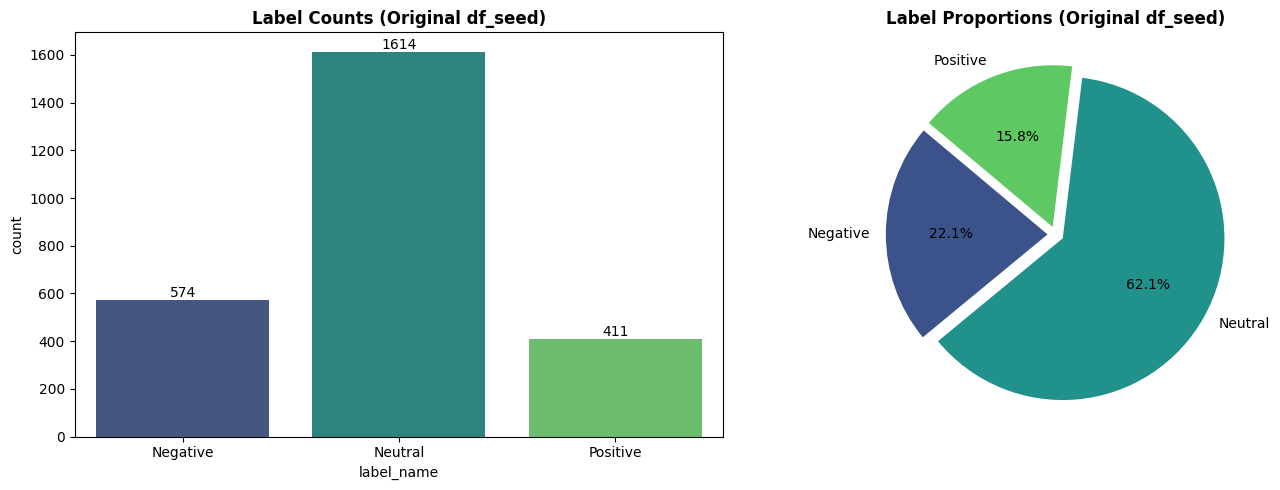


SPLITTING DATASET

TRAINING CONFIGURATION
Train Size : 2079 samples
Val Size   : 520 samples
------------------------------
Computed Class Weights (for Loss Function):
  Negative  : 2.2647
  Neutral   : 0.5368
  Positive  : 3.1596


In [33]:
# --- 0. Setup Visualization Function ---
def plot_label_distribution(df, target_col='label', title_suffix=''):
    viz_df = df.copy()
    unique_labels = set(viz_df[target_col].unique())
    if unique_labels.issubset({0, 1, 2}):
        label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'} 
    else:
        label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'} 
        
    viz_df['label_name'] = viz_df[target_col].map(label_map)
    order = ['Negative', 'Neutral', 'Positive']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(x='label_name', data=viz_df, order=order, palette='viridis', ax=ax1)
    ax1.set_title(f'Label Counts {title_suffix}', fontsize=12, fontweight='bold')
    
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black')

    counts = viz_df['label_name'].value_counts().reindex(order)
    ax2.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette('viridis', 3), explode=(0.05, 0.05, 0.05))
    ax2.set_title(f'Label Proportions {title_suffix}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- 1. Check & Visualize Distribution ---
print("="*50)
print("DATASET DISTRIBUTION (ORIGINAL)")
print("="*50)
plot_label_distribution(df_seed, target_col='label', title_suffix='(Original df_seed)')

# --- 2. Train/Val Split ---
print("\n" + "="*50)
print("SPLITTING DATASET")
print("="*50)

train_df, val_df = train_test_split(
    df_seed,
    test_size=0.2,
    stratify=df_seed['label'],
    random_state=SEED
)

# --- 3. Remap Labels ---
label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "negative", 1: "neutral", 2: "positive"}

train_df['label_id'] = train_df['label'].map(label_to_id)
val_df['label_id'] = val_df['label'].map(label_to_id)

# --- 4. Compute Class Weights ---
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)
class_weights = class_weights * np.array([1.5, 1.0, 1.5])
# PENTING: Variabel ini akan dipakai di model
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)
print(f"Train Size : {len(train_df)} samples")
print(f"Val Size   : {len(val_df)} samples")
print("-" * 30)
print("Computed Class Weights (for Loss Function):")
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    print(f"  {label:<10}: {class_weights[i]:.4f}")

# Tokenization & dataset prep

In [34]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False, # Padding handled by collator later
            return_tensors=None
        )
        
        return {
            'input_ids': encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
            'labels': label
        }

# Create Dataset Objects
train_dataset = SentimentDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_df['text'].tolist(), val_df['label_id'].tolist(), tokenizer, MAX_LENGTH)

print("✅ Dataset and Tokenizer ready.")

✅ Dataset and Tokenizer ready.


# Model architecture definition (CNN)

In [44]:
class IndoBERT_CNN_Classifier(nn.Module):
    def __init__(self, model_name, num_labels, id_to_label, label_to_id, 
                 class_weights=None, focal_gamma=2.0, 
                 num_filters=128, filter_sizes=[3, 4, 5], dropout=0.2):
        super(IndoBERT_CNN_Classifier, self).__init__()
        
        self.bert = AutoModel.from_pretrained(model_name)
        self.id_to_label = id_to_label
        self.label_to_id = label_to_id
        
        # Focal Loss parameters
        self.class_weights = class_weights
        self.focal_gamma = focal_gamma
        
        # CNN Layers
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=768, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # [batch_size, seq_len, 768] -> [batch_size, 768, seq_len]
        x = outputs.last_hidden_state.transpose(1, 2)
        
        # CNN & Max Pooling
        x = [F.relu(conv(x)) for conv in self.convs]
        x = [F.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        
        # Concatenate & FC
        x = torch.cat(x, 1)
        x = self.dropout(x)
        logits = self.fc(x)

        loss = None
        if labels is not None:
            # Hitung Focal Loss di sini
            ce_loss = F.cross_entropy(logits, labels, weight=self.class_weights, reduction='none')
            pt = torch.exp(-ce_loss)
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss

        # Return standard Hugging Face output object
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

# Customize trainer & metrics

In [47]:
class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.focal_gamma = focal_gamma
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        
        # FIX: Model mengembalikan tuple (loss, logits) jika ada labels
        # Jadi kita ambil index ke-1 untuk logits
        if isinstance(outputs, tuple):
            logits = outputs[1]
        else:
            # Fallback jika model mengembalikan object lain (misal saat eval tanpa label)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs
        
        ce_loss = F.cross_entropy(logits, labels, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        
        return (focal_loss, outputs) if return_outputs else focal_loss

def compute_metrics(pred):
    labels = pred.label_ids
    # Karena model return SequenceClassifierOutput, Trainer otomatis ekstrak logits
    preds = pred.predictions 
    preds = np.argmax(preds, axis=1)
    
    f1_per_class = f1_score(labels, preds, average=None)
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
    }

# Training initialization

In [48]:
target_names = train_df['label_id'].unique().tolist()

sentiment_model = IndoBERT_CNN_Classifier(
    model_name=MODEL_NAME,
    num_labels=len(target_names),
    id_to_label=id_to_label,
    label_to_id=label_to_id,
    num_filters=128,
    filter_sizes=[3, 4, 5],
    dropout=DROPOUT
).to(device)

training_args = TrainingArguments(
    output_dir=f"{MODEL_PATH}/sentiment_training",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    learning_rate=3e-5,
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_dir=f"{MODEL_PATH}/logs",
    logging_steps=50,
    report_to="none",
    fp16=True,
    dataloader_num_workers=2,
    seed=SEED,
)

trainer = FocalLossTrainer(
    class_weights=class_weights_tensor,
    focal_gamma=2.0,
    model=sentiment_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer Initialized.")

✅ Trainer Initialized.


# Execute training

In [ ]:
print("="*40)
print("🚀 STARTING TRAINING")
print("="*40)

trainer.train()

print("✅ Training Complete.")

🚀 STARTING TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1 Negative,F1 Neutral,F1 Positive
1,0.943200,0.662365,0.313462,0.319009,0.236381,0.500000,0.115942,0.341085
2,0.674700,0.538689,0.457692,0.463548,0.427545,0.652439,0.360000,0.378205
3,0.491000,0.377291,0.636538,0.631598,0.651137,0.769811,0.654832,0.470149


# evaluation

In [ ]:
print("Running Final Evaluation...")

# Predict
pred = trainer.predict(val_dataset)
y_true = pred.label_ids

# FIX: Handle tuple output from prediction
if isinstance(pred.predictions, tuple):
    # Output biasanya (loss, logits) atau (logits, ...)
    # Karena saat predict loss dikembalikan jika label ada
    logits = pred.predictions[1] 
else:
    logits = pred.predictions

y_pred = np.argmax(logits, axis=1)

# Metrics
final_metrics = trainer.evaluate()

print("\n" + "="*50)
print("FINAL RESULTS (IndoBERT + CNN)")
print("="*50)
print(f"Accuracy    : {final_metrics['eval_accuracy']:.4f}")
print(f"Macro F1    : {final_metrics['eval_macro_f1']:.4f}")
print(f"Weighted F1 : {final_metrics['eval_weighted_f1']:.4f}")
print("-" * 50)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"], digits=4))

In [ ]:
# Save Model (before ablation)
import json

os.makedirs(f'{MODEL_PATH}/cnn_best', exist_ok=True)
torch.save(sentiment_model.state_dict(), f'{MODEL_PATH}/cnn_best/model_state_dict.pt')
tokenizer.save_pretrained(f'{MODEL_PATH}/cnn_best')
print(f'[OK] Model saved -> {MODEL_PATH}/cnn_best/model_state_dict.pt')

summary = {
    'model': 'IndoBERT + CNN',
    'architecture': f'[CLS] -> CNN(filters={NUM_FILTERS}, kernels={KERNEL_SIZES}) -> MaxPool -> Linear -> Softmax',
    'indobert': MODEL_NAME, 'max_length': MAX_LENGTH, 'dropout': DROPOUT,
    'results': {
        'accuracy'   : float(final_metrics['eval_accuracy']),
        'macro_f1'   : float(final_metrics['eval_macro_f1']),
        'weighted_f1': float(final_metrics['eval_weighted_f1']),
    },
    'data': {'train_samples': len(train_df), 'val_samples': len(val_df)},
}
with open(f'{MODEL_PATH}/cnn_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'[OK] Summary saved -> {MODEL_PATH}/cnn_summary.json')
print(json.dumps(summary['results'], indent=2))

In [ ]:
!pip install PySastrawi

In [ ]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

def plot_evaluation_results(y_true, y_pred, df_val):
    target_names = ["Negative", "Neutral", "Positive"]
    
    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

    # --- 2. Per-Class Metrics ---
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    metrics_df = pd.DataFrame({
        'Class': target_names * 3,
        'Score': np.concatenate([precision, recall, f1]),
        'Metric': ['Precision']*3 + ['Recall']*3 + ['F1-Score']*3
    })
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df, palette='viridis')
    plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.show()

    # --- 3. Word Clouds ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT")
    print("="*50)
    
    factory = StopWordRemoverFactory()
    stopword_remover = factory.create_stop_word_remover()
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Filter berdasarkan label_id di df_val
        raw_subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if raw_subset_text:
            cleaned_text = stopword_remover.remove(raw_subset_text)
        else:
            cleaned_text = "No Data"
            
        wc = WordCloud(
            width=800, height=400, background_color='white', 
            colormap='viridis', max_words=100
        ).generate(cleaned_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Panggil fungsi
plot_evaluation_results(y_true, y_pred, val_df)

# ABLATION STUDY 1 — CNN Kernel Size (Filter Size) Variants
## Reviewer Comment: Justify choice of filter sizes [3,4,5]
**Reference:** Kim (2014), "Convolutional Neural Networks for Sentence Classification", EMNLP 2014.

In [ ]:
print("="*70)
print("ABLATION STUDY 1 — CNN KERNEL SIZE VARIANTS")
print("Ref: Kim (2014), EMNLP 2014")
print("="*70)

kernel_variants = [
    ([3, 4, 5], "Paper Setting"),
    ([2, 3, 4], "Smaller Kernels"),
    ([3, 5, 7], "Larger Kernels"),
]
ablation1_results = {}

for filter_sizes_abl, desc in kernel_variants:
    marker = " <- PAPER SETTING" if filter_sizes_abl == [3,4,5] else ""
    print(f"\n--- filter_sizes={filter_sizes_abl} ({desc}){marker} ---")
    set_seed(SEED)

    model_abl1 = IndoBERT_CNN_Classifier(
        model_name=MODEL_NAME,
        num_labels=3,
        id_to_label=id_to_label,
        label_to_id=label_to_id,
        class_weights=class_weights_tensor,
        focal_gamma=2.0,
        num_filters=128,
        filter_sizes=filter_sizes_abl,
        dropout=DROPOUT
    ).to(device)

    abl1_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/abl1_kernel{''.join(map(str,filter_sizes_abl))}",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=16, per_device_eval_batch_size=16,
        gradient_accumulation_steps=2, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    abl1_trainer = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=2.0,
        model=model_abl1, args=abl1_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    abl1_trainer.train()

    pred_abl1 = abl1_trainer.predict(val_dataset)
    raw_preds = pred_abl1.predictions
    logits_abl1 = raw_preds[1] if isinstance(raw_preds, tuple) else raw_preds
    y_pred_abl1 = np.argmax(logits_abl1, axis=1)
    f1_per = f1_score(y_true, y_pred_abl1, average=None)

    key = str(filter_sizes_abl)
    ablation1_results[key] = {
        'desc': desc,
        'macro_f1':    f1_score(y_true, y_pred_abl1, average='macro'),
        'accuracy':    accuracy_score(y_true, y_pred_abl1),
        'weighted_f1': f1_score(y_true, y_pred_abl1, average='weighted'),
        'f1_neg': f1_per[0], 'f1_neu': f1_per[1], 'f1_pos': f1_per[2],
    }
    r = ablation1_results[key]
    print(f"  Macro F1={r['macro_f1']:.4f}, Acc={r['accuracy']:.4f}, F1-Neg={r['f1_neg']:.4f}, F1-Pos={r['f1_pos']:.4f}{marker}")

    del model_abl1, abl1_trainer
    torch.cuda.empty_cache()

# ── Table ──
print("\nABLATION 1 SUMMARY TABLE:")
print(f"{'Filter Sizes':<15} {'Desc':<18} {'Macro F1':>9} {'Accuracy':>9} {'F1-Neg':>8} {'F1-Pos':>8}")
print("-"*70)
for k, r in ablation1_results.items():
    marker = " <-Paper" if r['desc'] == "Paper Setting" else ""
    print(f"{k:<15} {r['desc']:<18} {r['macro_f1']:>9.4f} {r['accuracy']:>9.4f} {r['f1_neg']:>8.4f} {r['f1_pos']:>8.4f}{marker}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
keys_abl1 = list(ablation1_results.keys())
x_labels_abl1 = [f"{k}\n({ablation1_results[k]['desc']})" for k in keys_abl1]
colors_abl1 = ['#FF5722' if ablation1_results[k]['desc']=='Paper Setting' else '#2196F3' for k in keys_abl1]

axes[0].bar(x_labels_abl1, [ablation1_results[k]['macro_f1'] for k in keys_abl1], color=colors_abl1)
for i, v in enumerate([ablation1_results[k]['macro_f1'] for k in keys_abl1]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)
axes[0].set_title('Macro F1 per Kernel Config', fontweight='bold')
axes[0].set_ylim(0, 1.05)

x_k = np.arange(len(keys_abl1)); w_k = 0.35
axes[1].bar(x_k - w_k/2, [ablation1_results[k]['f1_neg'] for k in keys_abl1], w_k, label='F1-Negative', color='#E53935')
axes[1].bar(x_k + w_k/2, [ablation1_results[k]['f1_pos'] for k in keys_abl1], w_k, label='F1-Positive', color='#43A047')
axes[1].set_xticks(x_k); axes[1].set_xticklabels(x_labels_abl1)
axes[1].set_title('Minority Class F1 per Kernel Config', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend()

fig.suptitle('Ablation Study 1: CNN Filter/Kernel Size Variants (Orange = Paper Setting)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ablation1_kernel_sizes.png", dpi=150)
plt.show()

# ABLATION STUDY 2 — Number of CNN Filters Variants
## Reviewer Comment: Justify choice of num_filters=128
**Reference:** Zhang & Wallace (2015), "A Sensitivity Analysis of CNN for Sentence Classification", TACL.

In [ ]:
print("="*70)
print("ABLATION STUDY 2 — NUMBER OF CNN FILTERS VARIANTS")
print("Ref: Zhang & Wallace (2015), TACL")
print("="*70)

filter_count_variants = [64, 128, 256]  # 128 = paper setting
ablation2_results = {}

for num_f in filter_count_variants:
    marker = " <- PAPER SETTING" if num_f == 128 else ""
    print(f"\n--- num_filters={num_f}{marker} ---")
    set_seed(SEED)

    model_abl2 = IndoBERT_CNN_Classifier(
        model_name=MODEL_NAME,
        num_labels=3,
        id_to_label=id_to_label,
        label_to_id=label_to_id,
        class_weights=class_weights_tensor,
        focal_gamma=2.0,
        num_filters=num_f,
        filter_sizes=[3, 4, 5],
        dropout=DROPOUT
    ).to(device)

    abl2_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/abl2_filters{num_f}",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=16, per_device_eval_batch_size=16,
        gradient_accumulation_steps=2, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    abl2_trainer = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=2.0,
        model=model_abl2, args=abl2_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    abl2_trainer.train()

    pred_abl2 = abl2_trainer.predict(val_dataset)
    raw_preds2 = pred_abl2.predictions
    logits_abl2 = raw_preds2[1] if isinstance(raw_preds2, tuple) else raw_preds2
    y_pred_abl2 = np.argmax(logits_abl2, axis=1)
    f1_per2 = f1_score(y_true, y_pred_abl2, average=None)
    total_params_abl2 = sum(p.numel() for p in model_abl2.parameters())

    ablation2_results[num_f] = {
        'macro_f1':    f1_score(y_true, y_pred_abl2, average='macro'),
        'accuracy':    accuracy_score(y_true, y_pred_abl2),
        'weighted_f1': f1_score(y_true, y_pred_abl2, average='weighted'),
        'f1_neg': f1_per2[0], 'f1_neu': f1_per2[1], 'f1_pos': f1_per2[2],
        'total_params': total_params_abl2,
    }
    r2 = ablation2_results[num_f]
    print(f"  Macro F1={r2['macro_f1']:.4f}, Params={total_params_abl2:,}{marker}")

    del model_abl2, abl2_trainer
    torch.cuda.empty_cache()

# ── Table ──
print("\nABLATION 2 SUMMARY TABLE:")
print(f"{'Num Filters':>12} {'Macro F1':>9} {'Accuracy':>9} {'F1-Neg':>8} {'F1-Pos':>8} {'Params':>12}")
print("-"*65)
for n, r in ablation2_results.items():
    marker = " <-Paper" if n == 128 else ""
    print(f"{n:>12} {r['macro_f1']:>9.4f} {r['accuracy']:>9.4f} {r['f1_neg']:>8.4f} {r['f1_pos']:>8.4f} {r['total_params']:>12,}{marker}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
nf_keys = list(ablation2_results.keys())
x_nf = [str(n) + ('\n(Paper)' if n==128 else '') for n in nf_keys]
colors_nf = ['#FF5722' if n==128 else '#2196F3' for n in nf_keys]

axes[0].bar(x_nf, [ablation2_results[n]['macro_f1'] for n in nf_keys], color=colors_nf)
for i, v in enumerate([ablation2_results[n]['macro_f1'] for n in nf_keys]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)
axes[0].set_title('Macro F1 per Num Filters', fontweight='bold')
axes[0].set_ylim(0, 1.05)

axes[1].bar(x_nf, [ablation2_results[n]['total_params']/1e6 for n in nf_keys], color=colors_nf)
for i, v in enumerate([ablation2_results[n]['total_params']/1e6 for n in nf_keys]):
    axes[1].text(i, v + 0.1, f'{v:.1f}M', ha='center', fontsize=11)
axes[1].set_title('Total Parameters (Millions)', fontweight='bold')

fig.suptitle('Ablation Study 2: Number of CNN Filters (Orange = Paper Setting)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ablation2_num_filters.png", dpi=150)
plt.show()

# ABLATION STUDY 3 — CNN Pooling Strategy Variants
## Reviewer Comment: Justify choice of max pooling after CNN
**Reference:** Boureau et al. (2010), "A Theoretical Analysis of Feature Pooling in Visual Recognition", ICML 2010.

In [ ]:
print("="*70)
print("ABLATION STUDY 3 — CNN POOLING STRATEGY VARIANTS")
print("Ref: Boureau et al. (2010), ICML 2010")
print("="*70)

# Variant model supporting different pooling strategies
class IndoBERT_CNN_PoolingVariant(nn.Module):
    def __init__(self, model_name, num_labels=3, id_to_label=None, label_to_id=None,
                 class_weights=None, focal_gamma=2.0,
                 num_filters=128, filter_sizes=[3,4,5], dropout=0.2,
                 pooling='max', k_max=3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.pooling = pooling
        self.k_max = k_max
        self.class_weights = class_weights
        self.focal_gamma = focal_gamma
        self.convs = nn.ModuleList([
            nn.Conv1d(768, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        # k-max pooling outputs k values per filter → k * num_filters * len(filter_sizes)
        out_dim = len(filter_sizes) * num_filters * k_max if pooling == 'kmax' else len(filter_sizes) * num_filters
        self.fc = nn.Linear(out_dim, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # [batch, seq, 768] -> [batch, 768, seq]
        x = outputs.last_hidden_state.transpose(1, 2)

        pooled = []
        for conv in self.convs:
            c = F.relu(conv(x))  # [batch, num_filters, seq-ks+1]
            if self.pooling == 'max':
                p = F.max_pool1d(c, c.size(2)).squeeze(2)
            elif self.pooling == 'avg':
                p = F.avg_pool1d(c, c.size(2)).squeeze(2)
            elif self.pooling == 'kmax':
                # k-max: take top-k values and flatten
                k = min(self.k_max, c.size(2))
                p, _ = c.topk(k, dim=2)          # [batch, num_filters, k]
                p = p.reshape(p.size(0), -1)      # [batch, num_filters * k]
            pooled.append(p)

        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        logits = self.fc(x)

        loss = None
        if labels is not None:
            ce_loss = F.cross_entropy(logits, labels, weight=self.class_weights, reduction='none')
            pt = torch.exp(-ce_loss)
            loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        return SequenceClassifierOutput(loss=loss, logits=logits)

pooling_variants = [
    ('max',  'Max Pooling (Paper)'),
    ('avg',  'Average Pooling'),
    ('kmax', 'K-Max Pooling (k=3)'),
]
ablation3_results = {}

for pool_type, pool_desc in pooling_variants:
    marker = " <- PAPER SETTING" if pool_type == 'max' else ""
    print(f"\n--- {pool_desc}{marker} ---")
    set_seed(SEED)

    model_abl3 = IndoBERT_CNN_PoolingVariant(
        model_name=MODEL_NAME, num_labels=3,
        id_to_label=id_to_label, label_to_id=label_to_id,
        class_weights=class_weights_tensor, focal_gamma=2.0,
        num_filters=128, filter_sizes=[3,4,5], dropout=DROPOUT,
        pooling=pool_type, k_max=3
    ).to(device)

    abl3_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/abl3_pool_{pool_type}",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=16, per_device_eval_batch_size=16,
        gradient_accumulation_steps=2, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    abl3_trainer = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=2.0,
        model=model_abl3, args=abl3_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    abl3_trainer.train()

    pred_abl3 = abl3_trainer.predict(val_dataset)
    raw3 = pred_abl3.predictions
    logits_abl3 = raw3[1] if isinstance(raw3, tuple) else raw3
    y_pred_abl3 = np.argmax(logits_abl3, axis=1)
    f1_per3 = f1_score(y_true, y_pred_abl3, average=None)

    ablation3_results[pool_type] = {
        'desc': pool_desc,
        'macro_f1':    f1_score(y_true, y_pred_abl3, average='macro'),
        'accuracy':    accuracy_score(y_true, y_pred_abl3),
        'weighted_f1': f1_score(y_true, y_pred_abl3, average='weighted'),
        'f1_neg': f1_per3[0], 'f1_neu': f1_per3[1], 'f1_pos': f1_per3[2],
    }
    r3 = ablation3_results[pool_type]
    print(f"  Macro F1={r3['macro_f1']:.4f}{marker}")

    del model_abl3, abl3_trainer
    torch.cuda.empty_cache()

# ── Table ──
print("\nABLATION 3 SUMMARY TABLE:")
print(f"{'Pooling':<10} {'Desc':<25} {'Macro F1':>9} {'Accuracy':>9} {'F1-Neg':>8} {'F1-Pos':>8}")
print("-"*75)
for pt, r in ablation3_results.items():
    marker = " <-Paper" if pt == 'max' else ""
    print(f"{pt:<10} {r['desc']:<25} {r['macro_f1']:>9.4f} {r['accuracy']:>9.4f} {r['f1_neg']:>8.4f} {r['f1_pos']:>8.4f}{marker}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
p_keys = list(ablation3_results.keys())
x_p = [ablation3_results[k]['desc'].replace(' Pooling','\nPooling') for k in p_keys]
colors_p = ['#FF5722' if k=='max' else '#2196F3' for k in p_keys]

axes[0].bar(x_p, [ablation3_results[k]['macro_f1'] for k in p_keys], color=colors_p)
for i, v in enumerate([ablation3_results[k]['macro_f1'] for k in p_keys]):
    axes[0].text(i, v+0.002, f'{v:.4f}', ha='center', fontsize=10)
axes[0].set_title('Macro F1 per Pooling Strategy', fontweight='bold')
axes[0].set_ylim(0, 1.05)

xp = np.arange(len(p_keys)); wp = 0.35
axes[1].bar(xp - wp/2, [ablation3_results[k]['f1_neg'] for k in p_keys], wp, label='F1-Negative', color='#E53935')
axes[1].bar(xp + wp/2, [ablation3_results[k]['f1_pos'] for k in p_keys], wp, label='F1-Positive', color='#43A047')
axes[1].set_xticks(xp); axes[1].set_xticklabels(x_p)
axes[1].set_title('Minority Class F1 per Pooling Strategy', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend()

fig.suptitle('Ablation Study 3: CNN Pooling Strategy Variants (Orange = Paper Setting)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ablation3_pooling.png", dpi=150)
plt.show()

# STRATIFIED 5-FOLD CROSS-VALIDATION
## Reviewer Comment: Single train/val split insufficient for generalization claims
**Reference:** Kohavi (1995), "A Study of Cross-Validation and Bootstrap for Accuracy Estimation", IJCAI-95.

In [ ]:
from sklearn.model_selection import StratifiedKFold

print("="*70)
print("STRATIFIED 5-FOLD CROSS-VALIDATION")
print("Ref: Kohavi (1995), IJCAI-95")
print("="*70)

N_FOLDS = 5
skf_cnn = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

all_texts_kf = df_seed['text'].values
all_labels_kf = df_seed['label'].map(label_to_id).values

fold_results_cnn = []

for fold, (train_idx, val_idx) in enumerate(skf_cnn.split(all_texts_kf, all_labels_kf)):
    print(f"\n{'='*40}\nFOLD {fold+1}/{N_FOLDS}\n{'='*40}")

    fold_train_texts = all_texts_kf[train_idx].tolist()
    fold_train_labels = all_labels_kf[train_idx].tolist()
    fold_val_texts   = all_texts_kf[val_idx].tolist()
    fold_val_labels  = all_labels_kf[val_idx].tolist()

    fold_cw = compute_class_weight('balanced', classes=np.unique(fold_train_labels), y=fold_train_labels)
    fold_cw = fold_cw * np.array([1.5, 1.0, 1.5])
    fold_cw_tensor = torch.FloatTensor(fold_cw).to(device)

    fold_train_ds = SentimentDataset(fold_train_texts, fold_train_labels, tokenizer, MAX_LENGTH)
    fold_val_ds   = SentimentDataset(fold_val_texts,   fold_val_labels,   tokenizer, MAX_LENGTH)

    set_seed(SEED)
    fold_model = IndoBERT_CNN_Classifier(
        model_name=MODEL_NAME, num_labels=3,
        id_to_label=id_to_label, label_to_id=label_to_id,
        class_weights=fold_cw_tensor, focal_gamma=2.0,
        num_filters=128, filter_sizes=[3,4,5], dropout=DROPOUT
    ).to(device)

    fold_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/kfold_cnn_fold{fold+1}",
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="macro_f1",
        save_total_limit=1, learning_rate=3e-5, num_train_epochs=15,
        per_device_train_batch_size=16, per_device_eval_batch_size=16,
        gradient_accumulation_steps=2, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    fold_trainer = FocalLossTrainer(
        class_weights=fold_cw_tensor, focal_gamma=2.0,
        model=fold_model, args=fold_args,
        train_dataset=fold_train_ds, eval_dataset=fold_val_ds,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    fold_trainer.train()

    fold_pred = fold_trainer.predict(fold_val_ds)
    fold_yt = fold_pred.label_ids
    raw_fp = fold_pred.predictions
    fold_yp = np.argmax(raw_fp[1] if isinstance(raw_fp, tuple) else raw_fp, axis=1)
    f1_per_fold = f1_score(fold_yt, fold_yp, average=None)

    result = {
        'fold': fold+1,
        'accuracy':    accuracy_score(fold_yt, fold_yp),
        'macro_f1':    f1_score(fold_yt, fold_yp, average='macro'),
        'weighted_f1': f1_score(fold_yt, fold_yp, average='weighted'),
        'f1_neg': f1_per_fold[0], 'f1_neu': f1_per_fold[1], 'f1_pos': f1_per_fold[2],
    }
    fold_results_cnn.append(result)
    print(f"Fold {fold+1} => Macro F1: {result['macro_f1']:.4f}, Acc: {result['accuracy']:.4f}")

    del fold_model, fold_trainer
    torch.cuda.empty_cache()

# ── Summary ──
print("\n" + "="*70)
print("5-FOLD CV SUMMARY (mean +/- std)")
print("="*70)
metrics_kf_cnn = ['accuracy', 'macro_f1', 'weighted_f1', 'f1_neg', 'f1_neu', 'f1_pos']
kfold_summary_cnn = {}
print(f"{'Metric':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-"*50)
for m in metrics_kf_cnn:
    vals = [r[m] for r in fold_results_cnn]
    mean_v, std_v = np.mean(vals), np.std(vals)
    kfold_summary_cnn[m] = {'mean': mean_v, 'std': std_v}
    print(f"{m:<15} {mean_v:>8.4f} {std_v:>8.4f} {min(vals):>8.4f} {max(vals):>8.4f}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5))
fold_nums = [r['fold'] for r in fold_results_cnn]
macro_f1s_kf = [r['macro_f1'] for r in fold_results_cnn]
mean_kf = np.mean(macro_f1s_kf); std_kf = np.std(macro_f1s_kf)
ax.plot(fold_nums, macro_f1s_kf, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.axhline(mean_kf, color='#FF5722', linestyle='--', linewidth=2,
           label=f'Mean: {mean_kf:.4f} +/- {std_kf:.4f}')
ax.fill_between(fold_nums, [mean_kf-std_kf]*N_FOLDS, [mean_kf+std_kf]*N_FOLDS,
                alpha=0.2, color='#FF5722')
for x, y in zip(fold_nums, macro_f1s_kf):
    ax.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
ax.set_xlabel('Fold'); ax.set_ylabel('Macro F1-Score')
ax.set_title('Stratified 5-Fold CV -- IndoBERT + CNN', fontweight='bold')
ax.legend(); ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/kfold_cv_cnn.png", dpi=150)
plt.show()
print(f"\nFinal: Macro F1 = {mean_kf:.4f} +/- {std_kf:.4f}")

# EXPLAINABLE AI — Integrated Gradients (Captum)
## Reviewer Comment: Model interpretability needed for political news domain
**Note:** CNN captures **local n-gram patterns** — attribution scores reflect which n-gram windows
(bigrams, trigrams, 4-grams based on kernel sizes 3,4,5) are most discriminative per class.

**Reference:** Sundararajan et al. (2017), "Axiomatic Attribution for Deep Networks", ICML 2017.

In [ ]:
try:
    from captum.attr import LayerIntegratedGradients
    print("Captum ready")
except ImportError:
    import subprocess; subprocess.run(["pip", "install", "captum", "-q"], check=True)
    from captum.attr import LayerIntegratedGradients
    print("Captum installed")

print("="*70)
print("EXPLAINABLE AI -- INTEGRATED GRADIENTS (CAPTUM)")
print("Ref: Sundararajan et al. (2017), ICML")
print("="*70)

xai_model_cnn = sentiment_model
xai_model_cnn.eval()

def predict_for_ig_cnn(input_ids_tensor):
    attn = (input_ids_tensor != tokenizer.pad_token_id).long()
    out = xai_model_cnn(input_ids=input_ids_tensor, attention_mask=attn)
    # Handle tuple output from CNN model
    if isinstance(out, tuple):
        return out[1] if len(out) > 1 else out[0]
    return out.logits

lig_cnn = LayerIntegratedGradients(predict_for_ig_cnn, xai_model_cnn.bert.embeddings.word_embeddings)

# 1 example per class
class_examples_cnn = {}
for idx in range(len(val_df)):
    lbl = int(val_df.iloc[idx]['label_id'])
    if lbl not in class_examples_cnn:
        class_examples_cnn[lbl] = str(val_df.iloc[idx]['text'])
    if len(class_examples_cnn) == 3:
        break

label_names_cnn = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for class_id in [0, 1, 2]:
    text_cnn = class_examples_cnn[class_id]
    enc = tokenizer(text_cnn, return_tensors='pt', truncation=True,
                    max_length=MAX_LENGTH, padding=True)
    input_ids_cnn = enc['input_ids'].to(device)
    baseline_ids  = torch.zeros_like(input_ids_cnn).to(device)

    attributions, _ = lig_cnn.attribute(
        inputs=input_ids_cnn, baselines=baseline_ids,
        target=class_id, n_steps=50, return_convergence_delta=True
    )

    attr_scores = attributions.squeeze(0).sum(dim=-1).detach().cpu().numpy()
    tokens_cnn  = tokenizer.convert_ids_to_tokens(input_ids_cnn.squeeze(0).cpu().numpy())

    top10_idx    = np.argsort(np.abs(attr_scores))[::-1][:10]
    top10_tokens = [tokens_cnn[i] for i in top10_idx]
    top10_scores = [attr_scores[i] for i in top10_idx]

    colors_ig = ['#E53935' if s < 0 else '#43A047' for s in top10_scores]
    axes[class_id].barh(range(10), top10_scores[::-1], color=colors_ig[::-1])
    axes[class_id].set_yticks(range(10))
    axes[class_id].set_yticklabels(top10_tokens[::-1], fontsize=10)
    axes[class_id].set_title(
        f'{label_names_cnn[class_id]} Class -- Top-10 Attribution Tokens\n'
        f'(CNN captures local n-gram patterns via kernel sizes [3,4,5]: these tokens form'
        f' the most discriminative bigram/trigram/4-gram windows)',
        fontweight='bold'
    )
    axes[class_id].axvline(x=0, color='black', linewidth=0.8)
    axes[class_id].set_xlabel('Attribution Score (green=positive contribution, red=negative)')

plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/xai_cnn_integrated_gradients.png", dpi=150, bbox_inches='tight')
plt.show()
print("XAI done!")
print("Note: Unlike RNN/Transformer, CNN attribution reflects LOCAL n-gram importance.")
print("High-attribution tokens tend to co-occur in windows of size 3, 4, or 5.")

# COMPUTATIONAL EFFICIENCY ANALYSIS
## Reviewer Comment: Report computational cost and compare with other architectures
**Reference:** Strubell et al. (2019), "Energy and Policy Considerations for Deep Learning in NLP", ACL 2019.

In [ ]:
import time

print("="*70)
print("COMPUTATIONAL EFFICIENCY ANALYSIS -- IndoBERT + CNN")
print("Ref: Strubell et al. (2019), ACL 2019")
print("="*70)

# ── 1. Parameter Count ──
print("\n1. PARAMETER COUNT PER COMPONENT")
print("-"*50)
bert_p    = sum(p.numel() for p in sentiment_model.bert.parameters())
cnn_p     = sum(p.numel() for p in sentiment_model.convs.parameters())
clf_p     = sum(p.numel() for p in sentiment_model.fc.parameters())
drop_p    = sum(p.numel() for p in sentiment_model.dropout.parameters())
total_p   = sum(p.numel() for p in sentiment_model.parameters())
train_p   = sum(p.numel() for p in sentiment_model.parameters() if p.requires_grad)

print(f"  IndoBERT (bert):     {bert_p:>12,}  ({bert_p/total_p*100:.1f}%)")
print(f"  CNN conv layers:     {cnn_p:>12,}  ({cnn_p/total_p*100:.1f}%)")
print(f"  Classifier (fc):     {clf_p:>12,}  ({clf_p/total_p*100:.1f}%)")
print(f"  {'─'*40}")
print(f"  TOTAL:               {total_p:>12,}")
print(f"  Trainable:           {train_p:>12,}")

# CNN architecture note
num_kernels = 3  # [3,4,5]
num_filters_ce = 128
print(f"\n  CNN design: {num_kernels} kernel sizes x {num_filters_ce} filters = {num_kernels*num_filters_ce} total feature maps")
print(f"  Parallel convolutions capture n-gram patterns at scales 3, 4, 5")

# ── 2. Single-sample Latency (50 runs, 5 warmup) ──
print("\n2. SINGLE-SAMPLE INFERENCE LATENCY (50 runs, 5 warmup)")
print("-"*50)
sentiment_model.eval()
sample_enc = tokenizer(
    str(val_df.iloc[0]['text']), return_tensors='pt',
    truncation=True, max_length=128, padding=True
)
s_ids = sample_enc['input_ids'].to(device)
s_msk = sample_enc['attention_mask'].to(device)

# Warmup
with torch.no_grad():
    for _ in range(5): sentiment_model(input_ids=s_ids, attention_mask=s_msk)

latency_runs = []
for _ in range(50):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        sentiment_model(input_ids=s_ids, attention_mask=s_msk)
    torch.cuda.synchronize()
    latency_runs.append((time.perf_counter() - t0) * 1000)

print(f"  Mean latency:  {np.mean(latency_runs):.2f} ms")
print(f"  Std latency:   {np.std(latency_runs):.2f} ms")
print(f"  P95 latency:   {np.percentile(latency_runs, 95):.2f} ms")

# ── 3. Throughput per Batch Size ──
print("\n3. THROUGHPUT (samples/sec) BY BATCH SIZE")
print("-"*50)
batch_sizes_lat = [1, 4, 8, 16]
latency_results_cnn = {}

for bs in batch_sizes_lat:
    sample_txts = val_df['text'].tolist()[:bs]
    sample_txts = (sample_txts * (bs // len(sample_txts) + 1))[:bs]
    enc_b = tokenizer(sample_txts, return_tensors='pt', truncation=True,
                      max_length=128, padding=True)
    iids = enc_b['input_ids'].to(device)
    amsk = enc_b['attention_mask'].to(device)

    with torch.no_grad():
        for _ in range(3): sentiment_model(input_ids=iids, attention_mask=amsk)

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    N_R = 10
    with torch.no_grad():
        for _ in range(N_R): sentiment_model(input_ids=iids, attention_mask=amsk)
    torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / N_R

    latency_results_cnn[bs] = {'latency_ms': elapsed*1000, 'throughput': bs/elapsed}
    print(f"  Batch={bs:2d}: {elapsed*1000:.1f} ms | {bs/elapsed:.0f} samples/s")

# ── 4. GPU Memory ──
print("\n4. GPU MEMORY USAGE")
print("-"*50)
if torch.cuda.is_available():
    print(f"  Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"  Reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")
    print(f"  Peak:      {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bss = list(latency_results_cnn.keys())
axes[0].plot(bss, [latency_results_cnn[b]['latency_ms'] for b in bss],
             'o-', color='#2196F3', linewidth=2, markersize=8)
for x, y in zip(bss, [latency_results_cnn[b]['latency_ms'] for b in bss]):
    axes[0].annotate(f'{y:.0f}ms', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
axes[0].set_xlabel('Batch Size'); axes[0].set_ylabel('Latency (ms)')
axes[0].set_title('Inference Latency vs Batch Size', fontweight='bold')

axes[1].plot(bss, [latency_results_cnn[b]['throughput'] for b in bss],
             's-', color='#FF5722', linewidth=2, markersize=8)
for x, y in zip(bss, [latency_results_cnn[b]['throughput'] for b in bss]):
    axes[1].annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Throughput (samples/sec)')
axes[1].set_title('Inference Throughput vs Batch Size', fontweight='bold')

fig.suptitle('Computational Efficiency Analysis -- IndoBERT + CNN', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/computational_efficiency_cnn.png", dpi=150)
plt.show()

# STATISTICAL SIGNIFICANCE TESTING
## Reviewer Comment: Prove performance differences are statistically significant
**References:**
- McNemar (1947), "Note on the sampling error of the difference between correlated proportions"
- Dror et al. (2018), "Deep Dominance — How to Properly Compare Deep Neural Models", ACL P18-1128.

In [ ]:
from scipy.stats import chi2

print("="*70)
print("STATISTICAL SIGNIFICANCE TESTING -- IndoBERT + CNN")
print("Refs: McNemar (1947); Dror et al. (2018), ACL P18-1128")
print("="*70)

# ── A. Bootstrap CI ──
print("\nA. BOOTSTRAP CONFIDENCE INTERVAL (n=1000, seed=42)")
print("-"*50)
np.random.seed(42)
N_BOOT = 1000
boot_f1s_cnn = []
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)

for _ in range(N_BOOT):
    idx_b = np.random.choice(len(y_true_arr), size=len(y_true_arr), replace=True)
    boot_f1s_cnn.append(f1_score(y_true_arr[idx_b], y_pred_arr[idx_b], average='macro'))

ci_lo = np.percentile(boot_f1s_cnn, 2.5)
ci_hi = np.percentile(boot_f1s_cnn, 97.5)
obs_f1_cnn = f1_score(y_true_arr, y_pred_arr, average='macro')

print(f"  Observed Macro F1 : {obs_f1_cnn:.4f}")
print(f"  Bootstrap Mean F1 : {np.mean(boot_f1s_cnn):.4f}")
print(f"  95% CI            : [{ci_lo:.4f}, {ci_hi:.4f}]")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_f1s_cnn, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(obs_f1_cnn, color='#FF5722', linewidth=2.5, label=f'Observed: {obs_f1_cnn:.4f}')
ax.axvline(ci_lo, color='#FF9800', linewidth=2, linestyle='--', label=f'95% CI Lower: {ci_lo:.4f}')
ax.axvline(ci_hi, color='#FF9800', linewidth=2, linestyle='--', label=f'95% CI Upper: {ci_hi:.4f}')
ax.set_xlabel('Macro F1-Score'); ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Macro F1 (n=1000) -- IndoBERT + CNN', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/bootstrap_ci_cnn.png", dpi=150)
plt.show()

# ── B. McNemar's Test vs GRU (best model) ──
print("\nB. McNEMAR'S TEST -- CNN vs GRU (best model)")
print("-"*50)
gru_path = "/kaggle/working/gru_val_preds.npy"

if os.path.exists(gru_path):
    y_pred_gru = np.load(gru_path)
    cnn_correct = (y_pred_arr == y_true_arr)
    gru_correct = (y_pred_gru == y_true_arr)

    b_mc = np.sum(cnn_correct & ~gru_correct)
    c_mc = np.sum(~cnn_correct & gru_correct)

    if (b_mc + c_mc) > 0:
        stat_mc = (abs(b_mc - c_mc) - 1)**2 / (b_mc + c_mc)
        p_mc    = 1 - chi2.cdf(stat_mc, df=1)
        gru_f1  = f1_score(y_true_arr, y_pred_gru, average='macro')

        print(f"  b={b_mc} (CNN correct, GRU wrong)  c={c_mc} (CNN wrong, GRU correct)")
        print(f"  McNemar chi2 = {stat_mc:.4f}")
        print(f"  p-value      = {p_mc:.4f}  {'SIGNIFICANT (p<0.05)' if p_mc < 0.05 else 'NOT SIGNIFICANT (p>=0.05)'}")
        print(f"  CNN  Macro F1 = {obs_f1_cnn:.4f}")
        print(f"  GRU  Macro F1 = {gru_f1:.4f}  (best model in paper)")
        print(f"  Delta = {obs_f1_cnn - gru_f1:+.4f}")
    else:
        print("  b+c=0: CNN and GRU made identical predictions.")
else:
    print(f"  WARNING: {gru_path} not found.")
    print("  -> Run the GRU notebook first to generate gru_val_preds.npy")
    print("  Bootstrap CI above is valid as standalone significance evidence.")

print("\nStatistical Significance Testing complete!")

# SAVE PREDICTIONS
Saved so other notebooks (BiLSTM, XGBoost, Random Forest) can run McNemar's test against GRU and CNN.

In [ ]:
np.save("/kaggle/working/cnn_val_preds.npy", y_pred)
np.save("/kaggle/working/cnn_val_true.npy",  y_true)

print("="*70)
print("CNN PREDICTIONS SAVED")
print("="*70)
print(f"  /kaggle/working/cnn_val_preds.npy  shape={np.array(y_pred).shape}")
print(f"  /kaggle/working/cnn_val_true.npy   shape={np.array(y_true).shape}")
print()
print("Used by other notebooks for McNemar's test.")
print()
print("Prediction distribution:")
u_p, c_p = np.unique(y_pred, return_counts=True)
for u, c in zip(u_p, c_p):
    print(f"  {id_to_label[u]:<10}: {c} ({c/len(y_pred)*100:.1f}%)")